# Reward vs Transition Revaluation

Here, we simulate reward estimation task from
`Giallanza et al. (2024)<https://direct.mit.edu/opmi/article/doi/10.1162/opmi_a_00143/12108>`_ (Study 1).

## Task

In an initial learning phase, the model sees two different sequences of three stimuli, each followed by a
different reward value. In a second, revaluation learning phase, the model sees sequences of two stimuli,
each beginning with the second stimulus in one of the sequences seen in the initial learning phase,
followed by one of two changes. In the reward *revaluation condition*, the sequence continued as in the
learning phase, but the reward associated with the two trajectories was swapped. In the
*transition revaluation* condition, the third stimulus was swapped between the two sequences, which was
then followed by the same reward that originally followed each of the third stimuli in the learning phase.
Finally, in a decision phase that followed each revaluation learning phase, the model estimates indicated its
preference between the starting states of the two trajectories by estimated the expected reward for
both ot them.






![experiment design](res/reval_experiment_design.png)

## Model

The model consists of an episodic memory module, a context (working memory) module, and a control unit
that controls if it is in "observation mode" or "estimation mode":

### Observation Mode

In observation mode, the model stores the current state, context, reward and a time value (implemented as
random drift on a sphere) to the episodic memory and updates its context by integrating the state.

### Estimation Mode

In estimation model, the model uses a "simulated context" to retrieve states. It successively uses these
retrieved states to update its simulated context.

In addition, the model can also use states to retrieve past contexts (instead of simulating them). In this
mode the model behaves like a model based RL model:
    - _Without_ context retrieval, the model successfully estimates rewards in the *reward revaluation* condition
     but not in the *transition revaluation* condition.
    - _With_ context retrieval, the model successfully estimates rewards in both conditions (similar to model based
    RL learning)

### Control

Control is implemented to switch between observation mode and estimation mode by controlling which inputs are
used to query the episodic memory and weather state or the retrieved state should update the (simulated) context.
It is also used to halt storing in estimation mode and to freeze the context in estimation mode.

****

*Jupyter Notebook Plumbing*

Add autoreload so that changes in the code are reflected in the notebook

In [1]:
import os.path
%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings('ignore')

## Task Environment

We first generate and visualize stimulus for a reward revaluation experiment only

In [2]:
from ego_revaluation.src import gen_trials
from ego_revaluation.src import utils

# For reproducibility, we set a global random seed
utils.set_random_seed(69)

# We can use convenience functions to generate reward and transition revaluation experiments:
experiment_reward_reval = gen_trials.gen_experiment_reward_reval()
experiment_transition_reval = gen_trials.gen_experiment_transition_reval()


### Inspect Trial Environment

**Baseline Trials**

| Sequence    | Reward |
|-------------|------|
| 1 -> 3 -> 5 | 10   |
| 2 -> 4 -> 6 | 1    |

**Reward Revaluation Trials**

| Sequence | Reward |
|--------|--------|
| 3 -> 5 | 1      |
| 4 -> 6 | 10     |


**Transition Reval Trials**

| Sequence | Reward |
|----------|------|
| 3 -> 6   | 10   |
| 4 -> 5   | 1    |



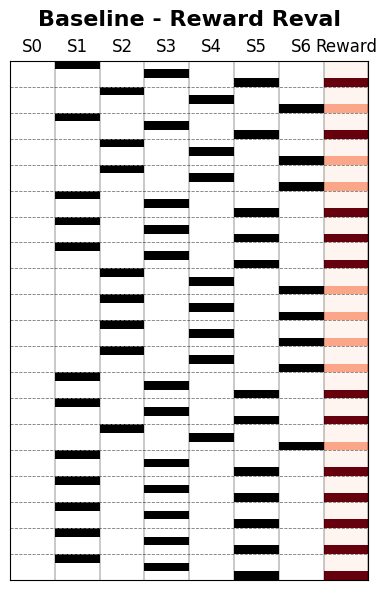

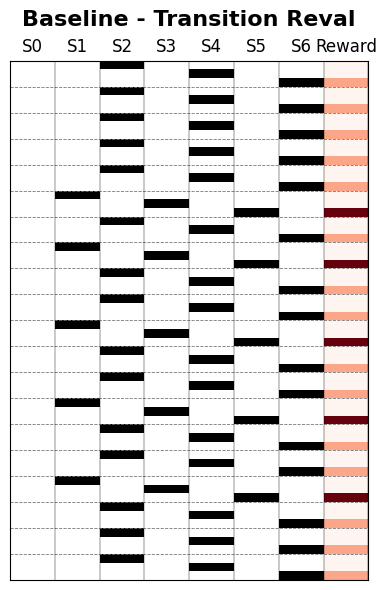

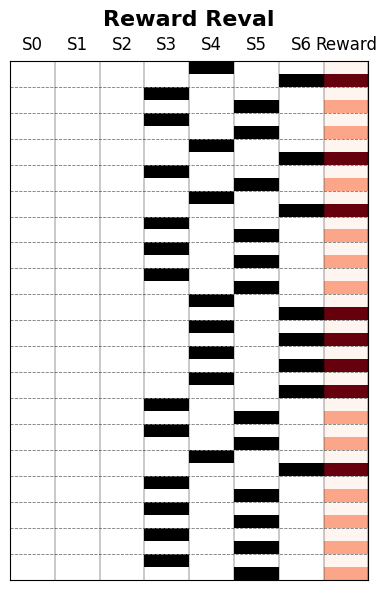

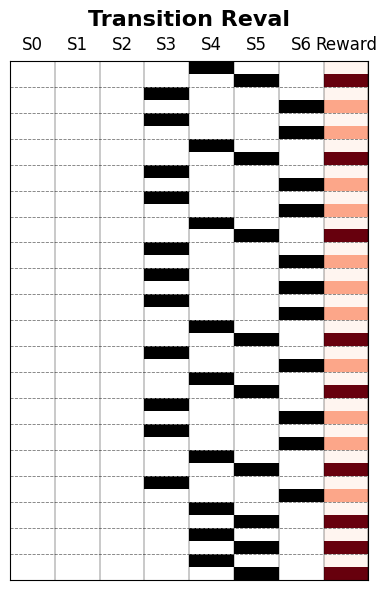

In [3]:
import ego_revaluation.src.plot as ego_plot

# Baselines
ego_plot.plot_trials(
    experiment_reward_reval.states_baseline,
    experiment_reward_reval.rewards_baseline,
    title='Baseline - Reward Reval',

)

ego_plot.plot_trials(
    experiment_transition_reval.states_baseline,
    experiment_transition_reval.rewards_baseline,
    title='Baseline - Transition Reval',
)

# Reward Revaluation
ego_plot.plot_trials(
    experiment_reward_reval.states_reval,
    experiment_reward_reval.rewards_reval,
    title='Reward Reval',
)

# Transition Revaluation
ego_plot.plot_trials(
    experiment_transition_reval.states_reval,
    experiment_transition_reval.rewards_reval,
    title='Transition Reval',
)

In [4]:
from ego_revaluation.model_pnl import construct_model
from ego_revaluation.config import defaults


def run_experiment(experiment,
                   context_retrieval=defaults.CONTEXT_RETRIEVE_IN_SIM,
                   time_retrieval=defaults.TIME_RETRIEVAL_WEIGHT,
                   ):
    model, state_input, time_input, reward_input, task_input = construct_model(
        capacity=experiment.n_trials,
        context_retrieval_in_sim=context_retrieval,
        time_retrieval_weight=time_retrieval,
    )

    state_1 = [0, 1, 0, 0, 0, 0, 0]
    state_2 = [0, 0, 1, 0, 0, 0, 0]

    input_baseline = {
        state_input: experiment.states_baseline,
        time_input: experiment.times_baseline,
        reward_input: experiment.rewards_baseline,
        task_input: experiment.tasks_baseline,
    }

    model.run(inputs=input_baseline)

    def get_reward_estimate(state):
        # run a query
        prediction_state_1 = {
            task_input: [1, 3, 2, 3, 2],
            state_input: [state] * 5,
            time_input: [experiment.times[-1]] * 5,
            reward_input: [0] * 5,
        }
        model.run(inputs=prediction_state_1)

        _res = model.results
        return _res[-1][1] + _res[-3][1] + _res[-5][1]

    re_baseline_state_1 = get_reward_estimate(state_1)
    re_baseline_state_2 = get_reward_estimate(state_2)

    inputs_reval = {
        state_input: experiment.states_reval,
        time_input: experiment.times_reval,
        reward_input: experiment.rewards_reval,
        task_input: experiment.tasks_reval,
    }
    model.run(inputs=inputs_reval)

    re_reval_state_1 = get_reward_estimate(state_1)
    re_reval_state_2 = get_reward_estimate(state_2)

    return {
        'context_retrieval': context_retrieval,
        'time_retrieval': time_retrieval,
        're_baseline_state_1': re_baseline_state_1,
        're_baseline_state_2': re_baseline_state_2,
        're_reval_state_1': re_reval_state_1,
        're_reval_state_2': re_reval_state_2,
    }

In [5]:
import os
import pandas as pd
import tqdm

csv_path = 'reward_vs_transition_reval_default.csv'

# load once (outside the loop)
if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
else:
    df = pd.DataFrame()

for _ in tqdm.tqdm(range(10)):
    experiment_reward_reval = gen_trials.gen_experiment_reward_reval()
    experiment_transition_reval = gen_trials.gen_experiment_transition_reval()

    observations_reward_reval = run_experiment(experiment_reward_reval)
    observations_transition_reval = run_experiment(experiment_transition_reval)

    # add condition labels
    observations_reward_reval['condition'] = 'reward_reval'
    observations_transition_reval['condition'] = 'transition_reval'

    # convert to df
    _df_reward = pd.DataFrame([observations_reward_reval])
    _df_transition = pd.DataFrame([observations_transition_reval])

    # append properly
    df = pd.concat([df, _df_reward, _df_transition], ignore_index=True)

# write once
df.to_csv(csv_path, index=False)

In [6]:
import random
for _ in range(10):
    experiment_reward_reval = gen_trials.gen_experiment_reward_reval()
    experiment_transition_reval = gen_trials.gen_experiment_transition_reval()
    context_retrieval = random.random()
    time_retrieval = random.random() * .5
    observations_reward_reval = run_experiment(experiment_reward_reval,
                                               context_retrieval=context_retrieval,
                                               time_retrieval=time_retrieval,
                                               )
    observations_transition_reval = run_experiment(experiment_transition_reval,
                                                   context_retrieval=context_retrieval,
                                                   time_retrieval=time_retrieval,)

    # store the observations to a df
    if os.path.exists('reward_vs_transition_reval_default.csv')



SyntaxError: expected ':' (3293742982.py, line 16)